# Desktop Summer Slump

**legacy_desktop DAU (28-day trailing moving average), global ALL.** Each year plotted May 1 → Sep 21 and indexed to its own May 1 value (May 1 = 100), so the *shape* of the summer dip is comparable across years regardless of absolute level. The 28d trailing MA removes the weekday/weekend sawtooth (same smoothing as the project's canonical curves).

- **2020–2025**: pure actuals.
- **2026**: actuals through the training seam (2026-07-05, solid) then the latest July forecast (dashed) — `desktop_locked/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet`, forecast_start 2026-07-06. The 28d-MA window blends continuously across the seam.


In [1]:
# [setup]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mozaic_daily.adjustments import load_forecast

FORECAST_PATH = "../../data-official/2026-07/desktop_locked/mozaic_daily_forecast.2026-07-06.ld-D.adj-lo.parquet"
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SUMMER_START_MD = (5, 1)    # May 1
SUMMER_END_MD = (9, 21)     # Sep 21 (astronomical summer)
YEARS = list(range(2020, 2027))  # 2027 is forecast-only, excluded (no May-1 actual anchor)

/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# [load-global-desktop]
df, meta = load_forecast(FORECAST_PATH)
df["target_date"] = pd.to_datetime(df["target_date"])

# Global top-line desktop DAU: all countries, all OS.
mask = (df.country == "ALL") & (df.app_name == "desktop") & (df.segment == '{"os": "ALL"}')
series = (
    df.loc[mask, ["target_date", "data_type", "dau"]]
    .sort_values("target_date")
    .reset_index(drop=True)
)

# 28-day trailing moving average (same smoothing used across the project's canonical curves).
# Computed on the full continuous daily series so the window blends across the 2026
# actual -> forecast seam exactly as the canonical 28d-MA outputs do.
series["dau_ma28"] = series["dau"].rolling(window=28, min_periods=28).mean()

print(f"{len(series)} daily rows, {series.target_date.min().date()} -> {series.target_date.max().date()}")
print("adjustments_applied:", [a.get("code") for a in meta.get("adjustments_applied", [])])
print("forecast begins:", series.loc[series.data_type == "forecast", "target_date"].min().date())
series.tail()


2922 daily rows, 2020-01-01 -> 2027-12-31
adjustments_applied: ['l', 'o']
forecast begins: 2026-07-06


,target_date,data_type,dau,dau_ma28
2917,2027-12-27,forecast,3.854452e+07,4.425901e+07
2918,2027-12-28,forecast,4.588515e+07,4.400952e+07
2919,2027-12-29,forecast,4.519548e+07,4.374108e+07
2920,2027-12-30,forecast,4.360655e+07,4.344146e+07
2921,2027-12-31,forecast,3.493251e+07,4.292135e+07


In [3]:
# [build-summer-frames]
def summer_slice(year, s):
    """May 1 -> Sep 21 window for one year, 28d-MA indexed to its May 1 value (= 100)."""
    start = pd.Timestamp(year, *SUMMER_START_MD)
    end = pd.Timestamp(year, *SUMMER_END_MD)
    sub = s[(s.target_date >= start) & (s.target_date <= end)].copy()
    anchor = sub.loc[sub.target_date == start, "dau_ma28"]
    if sub.empty or anchor.empty or pd.isna(anchor.iloc[0]):
        return None
    sub["days_since_may1"] = (sub.target_date - start).dt.days
    sub["index"] = sub.dau_ma28 / anchor.iloc[0] * 100.0
    sub["year"] = year
    return sub

frames = {y: summer_slice(y, series) for y in YEARS}
frames = {y: f for y, f in frames.items() if f is not None}
for y, f in frames.items():
    print(f"{y}: {len(f):>3}d  Sep21 index={f['index'].iloc[-1]:6.1f}  types={sorted(f.data_type.unique())}")


2020: 144d  Sep21 index=  95.9  types=['training']
2021: 144d  Sep21 index=  92.1  types=['training']
2022: 144d  Sep21 index=  98.5  types=['training']
2023: 144d  Sep21 index= 101.3  types=['training']
2024: 144d  Sep21 index=  96.8  types=['training']
2025: 144d  Sep21 index=  99.0  types=['training']
2026: 144d  Sep21 index=  98.4  types=['forecast', 'training']


saved /Users/brendanwells/work/mozaic-daily/research/summer-slump/plots/summer_slump_desktop_dau.png


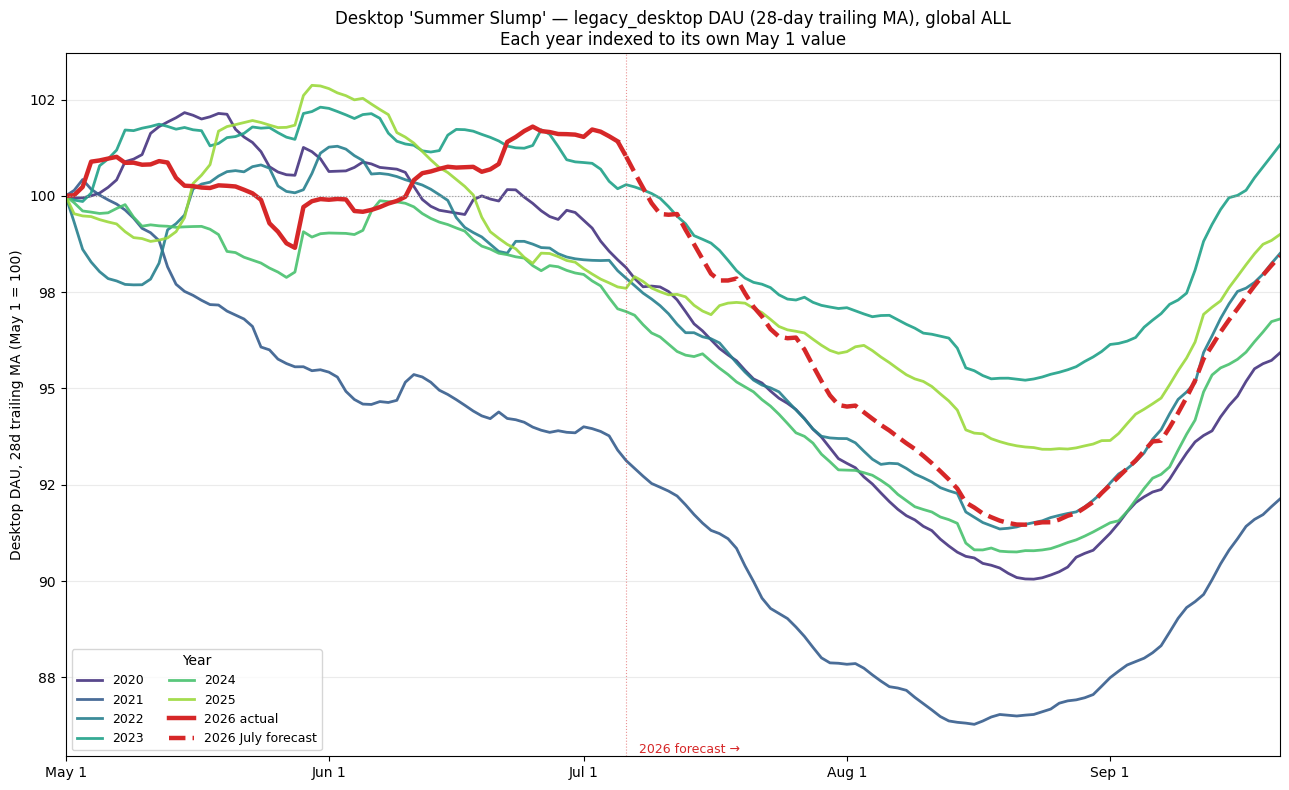

In [4]:
# [plot-summer-slump]
fig, ax = plt.subplots(figsize=(13, 8))

hist_years = [y for y in frames if y < 2026]
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(hist_years)))
color_by_year = dict(zip(hist_years, cmap))

for y in hist_years:
    f = frames[y]
    ax.plot(f.days_since_may1, f["index"], color=color_by_year[y], lw=2.0, alpha=0.9, label=str(y))

# 2026: actual (solid) + July forecast (dashed), standout red, bridged so the line is continuous.
RED = "#d62728"
f26 = frames[2026]
act = f26[f26.data_type == "training"]
fc = f26[f26.data_type == "forecast"]
ax.plot(act.days_since_may1, act["index"], color=RED, lw=3.2, label="2026 actual")
if not act.empty and not fc.empty:
    bridge = pd.concat([act.tail(1), fc.head(1)])
    ax.plot(bridge.days_since_may1, bridge["index"], color=RED, lw=3.2, ls="--")
ax.plot(fc.days_since_may1, fc["index"], color=RED, lw=3.2, ls="--", label="2026 July forecast")

# Month-boundary ticks (day offsets from May 1).
month_ticks = {
    (pd.Timestamp(2026, m, 1) - pd.Timestamp(2026, 5, 1)).days: lbl
    for m, lbl in [(5, "May 1"), (6, "Jun 1"), (7, "Jul 1"), (8, "Aug 1"), (9, "Sep 1")]
}
ax.set_xticks(list(month_ticks))
ax.set_xticklabels(list(month_ticks.values()))
ax.set_xlim(0, 143)

ax.axhline(100, color="0.6", lw=0.8, ls=":")
if not fc.empty:
    seam_x = fc.days_since_may1.iloc[0]
    ax.axvline(seam_x, color=RED, lw=0.8, ls=":", alpha=0.5)
    ax.text(seam_x + 1, ax.get_ylim()[0], " 2026 forecast →", color=RED, va="bottom", fontsize=9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.set_ylabel("Desktop DAU, 28d trailing MA (May 1 = 100)")
ax.set_title(
    "Desktop 'Summer Slump' — legacy_desktop DAU (28-day trailing MA), global ALL\n"
    "Each year indexed to its own May 1 value"
)
ax.legend(title="Year", ncol=2, loc="lower left", fontsize=9)
ax.grid(True, axis="y", alpha=0.25)

out = PLOTS_DIR / "summer_slump_desktop_dau.png"
fig.tight_layout()
fig.savefig(out, dpi=150, bbox_inches="tight")
print("saved", out.resolve())
plt.show()


In [5]:
# [summer-slump-table]
rows = []
for y, f in frames.items():
    trough = f.loc[f["index"].idxmin()]
    rows.append({
        "year": y,
        "may1_ma28": int(round(f.dau_ma28.iloc[0])),
        "sep21_index": round(f["index"].iloc[-1], 1),
        "trough_index": round(trough["index"], 1),
        "trough_date": trough.target_date.strftime("%b %d"),
    })
summary = pd.DataFrame(rows).set_index("year")
summary


,may1_ma28,sep21_index,trough_index,trough_date
year,,,,
2020,64375402,95.9,90.0,Aug 23
2021,64926628,92.1,86.3,Aug 16
2022,58225275,98.5,91.4,Aug 19
2023,53701965,101.3,95.2,Aug 22
2024,53714261,96.8,90.8,Aug 21
2025,50370018,99.0,93.4,Aug 25
2026,48098074,98.4,91.5,Aug 22
